In [1]:
# !pip install numpy
!pip install scipy --quiet
!pip install matplotlib --quiet
!pip install qutip --quiet

In [58]:
import time
# start time.time()

import numpy as np
from scipy.sparse import kron, identity, csr_matrix
from scipy.sparse.linalg import eigsh
import matplotlib.pyplot as plt
from qutip import *



In [59]:
X = np.array([[0, 1], [1, 0]], dtype=complex)
Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)
I = np.array([[1, 0], [0, 1]], dtype=complex)


In [60]:
def kron_n(ops):
    """Kronecker product of a list of operators."""
    result = ops[0]
    for op in ops[1:]:
        result = kron(result, op, format='csr')
    return result

In [61]:
def Hamiltonian(N, j, g):
    H = np.zeros((2**N, 2**N), dtype=complex)

    for i in range (N - 1):
        ops = [I] * N
        ops[i] = Z
        ops[(i + 1)] = Z
        H -= j * kron_n(ops)

    for i in range(N):
        ops = [I] * N
        ops[i] = X
        H -= g * kron_n(ops)

    H = Qobj(H, dims=[[2]*N, [2]*N])
    return H
        

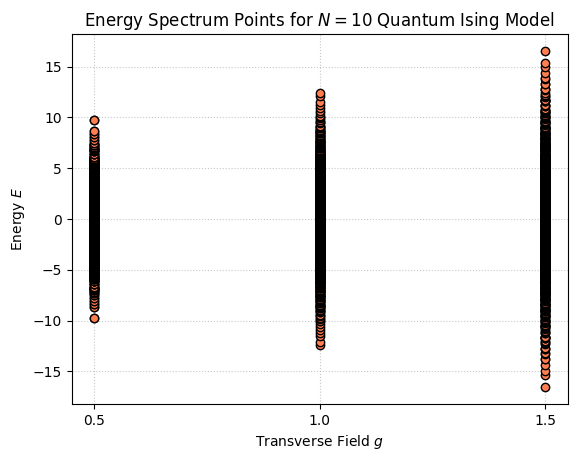


 
 Elapsed time: 1.9729 seconds


In [121]:


start = time.time()
n = 3
j = np.ones(n) + 0*np.random.rand(n)
g_init = 0.5
g_step = 0.5
g = np.arange(g_init, g_init + n * g_step, g_step)
N = 10


eigenvalues = [None] * n
eigenvectors = [None] * n

for i in range(0, n):
    H = Hamiltonian(N, j[i], g[i])
    # print(H)
    eigenvalues[i], eigenvectors[i] = np.linalg.eigh(H.full())



for i in range(0, n):
    x_val = g[i]
    y_vals = eigenvalues[i] 
    
    
    x_coords = np.array([x_val] * 2**N)
    
    plt.plot(x_coords, y_vals, marker='o', linestyle='None', color='coral', markersize=6, markeredgecolor='black')

plt.title(f'Energy Spectrum Points for $N={N}$ Quantum Ising Model')
plt.xlabel('Transverse Field $g$')
plt.ylabel('Energy $E$')
plt.xticks(g)
plt.grid(True, which='both', linestyle=':', alpha=0.7)
plt.show()

end = time.time()
print(f"\n \n Elapsed time: {end - start:.4f} seconds")

In [122]:
psi_gs = [None] * n
rho_AB = [None] * n
rho_A = [None] * n
S_A = [None] * n

D_AB = 2**N
N_A = N//2
N_B = N - N_A  
D_A = 2 ** (N_A)

keep_system = list(range(N_A))

for i in range(0, n):
    psi_gs[i] = Qobj(eigenvectors[i][:, 0], dims=[[2]*N, [1] ])
    rho_AB[i] = psi_gs[i] * psi_gs[i].dag()
    rho_A[i] = rho_AB[i].ptrace(keep_system)
    rho_A[i] = rho_A[i] / (rho_A[i].tr())
    S_A[i] = entropy_vn(rho_A[i], base=2)
    
    print(f"g = {g[i]:<5}  ρ_A = {rho_A[i].tr():<5} S_A = {S_A[i]:<5} ")


    

g = 0.5    ρ_A = 0.9999999999999998 S_A = 1.0014577038994572 
g = 1.0    ρ_A = 1.0   S_A = 0.5468570255336334 
g = 1.5    ρ_A = 0.9999999999999998 S_A = 0.22092054960617366 


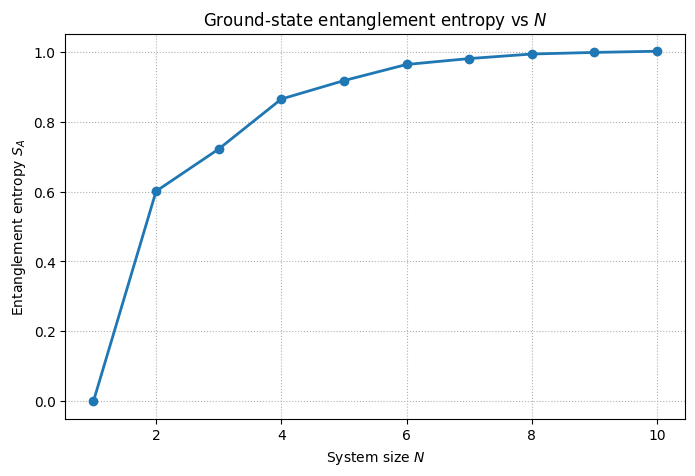

In [123]:
# N = 11
g_fixed = 0.5

Ns = np.arange(1, N + 1)
S_A = np.zeros(len(Ns))

for idx, k in enumerate(Ns):

    
    H = Hamiltonian(k, 1, g_fixed)

   
    eigvals, eigvect = np.linalg.eigh(H.full())
    psi_gs = Qobj(eigvect[:, 0], dims=[[2]*k, [1]])

    N_A = k // 2
    keep_system = list(range(N_A))

    rho_AB = psi_gs * psi_gs.dag()
    rho_A = rho_AB.ptrace(keep_system)

    S_A[idx] = entropy_vn(rho_A, base=2)


plt.figure(figsize=(8, 5))
plt.plot(Ns, S_A, 'o-', linewidth=2)
plt.xlabel('System size $N$')
plt.ylabel(r'Entanglement entropy $S_A$')
plt.title(r'Ground-state entanglement entropy vs $N$')
plt.grid(True, linestyle=':')
plt.show()

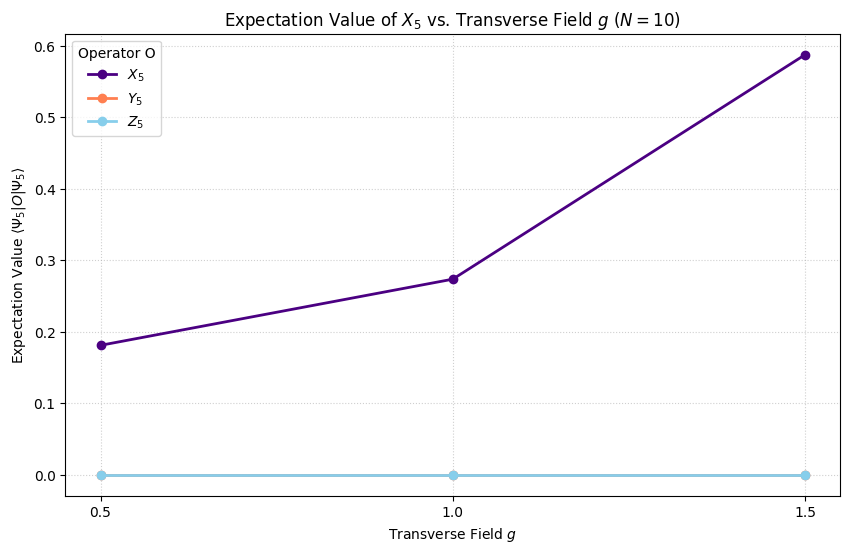

In [124]:


ops = [I] * N
ops[N//2] = X
O_x = Qobj(kron_n(ops).toarray(), dims=[[2]*N, [2]*N])

ops[N//2] = Y
O_y = Qobj(kron_n(ops).toarray(), dims=[[2]*N, [2]*N])

ops[N//2] = Z
O_z = Qobj(kron_n(ops).toarray(), dims=[[2]*N, [2]*N])

k = N//2
e_x = [None] * n
e_y = [None] * n
e_z = [None] * n
psi = [None] * n

for i in range(0, n):
    psi[i] = Qobj(eigenvectors[i][:, k], dims=[[2]*N, [1] * N])
    
    e_x[i] = expect(O_x, psi[i]).real
    e_y[i] = expect(O_y, psi[i]).real
    e_z[i] = expect(O_z, psi[i]).real




plt.figure(figsize=(10, 6))


plt.plot(g, e_x, marker='o', linestyle='-', color='indigo', linewidth=2, label=f'$X_{{{N//2}}}$')
plt.plot(g, e_y, marker='o', linestyle='-', color='coral', linewidth=2, label=f'$Y_{{{N//2}}}$')
plt.plot(g, e_z, marker='o', linestyle='-', color='skyblue', linewidth=2, label=f'$Z_{{{N//2}}}$')


plt.legend(title='Operator O', loc='best')
plt.title(f'Expectation Value of $X_{{{k}}}$ vs. Transverse Field $g$ ($N={N}$)')
plt.xlabel('Transverse Field $g$')
plt.ylabel(f'Expectation Value $\\langle \\Psi_{{{k}}} | O | \\Psi_{{{k}}} \\rangle$')
plt.xticks(g)
plt.grid(True, which='both', linestyle=':', alpha=0.6)
plt.show()

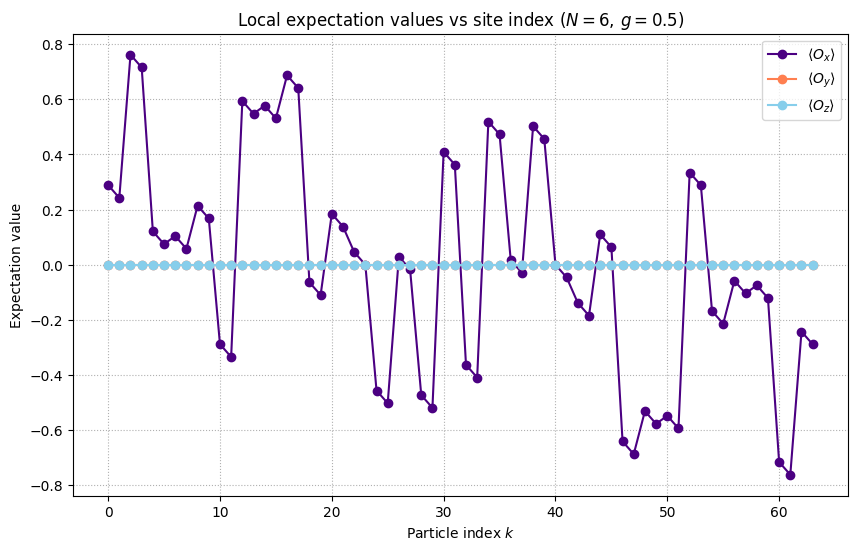

In [113]:
g_fixed = 0.5
# N = 10

ks = np.arange(0, 2**N )

H = Hamiltonian(N, 1, g_fixed)
eigvals, eigvect = np.linalg.eigh(H.full())


e_x = np.zeros(2**N)
e_y = np.zeros(2**N)
e_z = np.zeros(2**N)


for k in range(2**N):
    
    psi_gs = Qobj(eigvect[:, k], dims=[[2]*N, [1]])
    e_x[k] = expect(O_x, psi_gs).real
    e_y[k] = expect(O_y, psi_gs).real
    e_z[k] = expect(O_z, psi_gs).real


plt.figure(figsize=(10, 6))
plt.plot(ks, e_x, 'o-', color='indigo', label=r'$\langle O_x\rangle$')
plt.plot(ks, e_y, 'o-', color='coral', label=r'$\langle O_y\rangle$')
plt.plot(ks, e_z, 'o-', color='skyblue', label=r'$\langle O_z\rangle$')

plt.xlabel('Particle index $k$')
plt.ylabel('Expectation value')
plt.title(fr'Local expectation values vs site index ($N={N},\, g={g_fixed}$)')
plt.grid(True, linestyle=':')
plt.legend()
plt.show()

In [114]:

beta = 1
rho_beta = (-beta * H).expm()/ ((-beta * H).expm()).tr()
print((O_x * rho_beta).tr().real)
print(f"O_x = {(O_x * rho_beta).tr().real:<5} O_y = {(O_y * rho_beta).tr().real:<5} O_z = {(O_z * rho_beta).tr().real:<5} ")


0.2924766911564429
O_x = 0.2924766911564429 O_y = 0.0   O_z = 1.6653345369377348e-16 


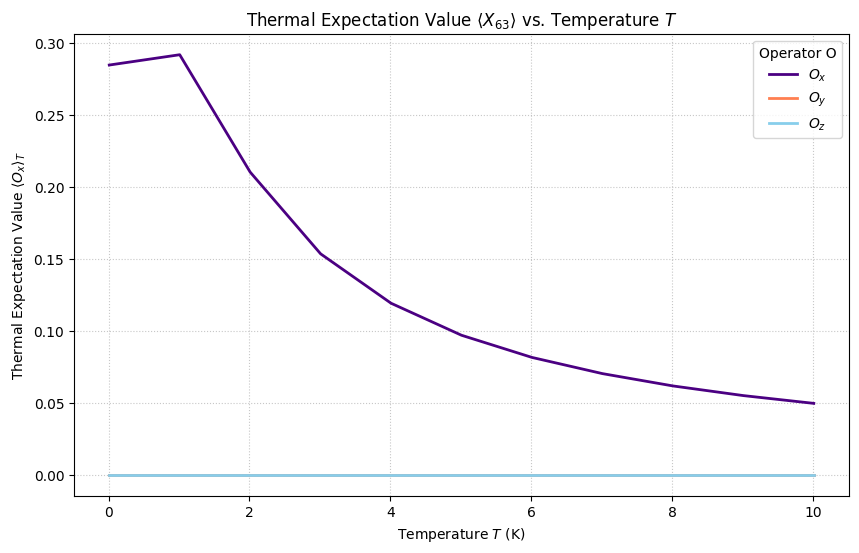

In [115]:
H = Hamiltonian(N, 1, 0.5)

k_B = 1
T_max = 10
T_min = 0.01
step_T = 1
T = np.arange(T_min, T_max + step_T, step_T)
E_th_x = np.zeros(len(T))
E_th_y = np.zeros(len(T))
E_th_z = np.zeros(len(T))

# print(T)

for i in range(0, len(T) ):
    beta = 1/(k_B * T[i])
    rho_beta = (-beta * H).expm()/ ((-beta * H).expm()).tr()
    E_th_x[i] = (O_x * rho_beta).tr().real
    E_th_y[i] = (O_y * rho_beta).tr().real
    E_th_z[i] = (O_z * rho_beta).tr().real

plt.figure(figsize=(10, 6))

plt.plot(T, E_th_x, linestyle='-', color='indigo', linewidth=2, label=f'$O_x$')
plt.plot(T, E_th_y, linestyle='-', color='coral', linewidth=2, label=f'$O_y$')
plt.plot(T, E_th_z, linestyle='-', color='skyblue', linewidth=2, label=f'$O_z$')

plt.legend(title='Operator O', loc='best')
plt.title(f'Thermal Expectation Value $\\langle X_{{{k}}}\\rangle$ vs. Temperature $T$')
plt.xlabel('Temperature $T$ (K)')
plt.ylabel('Thermal Expectation Value $\\langle O_x \\rangle_T$')
plt.grid(True, which='both', linestyle=':', alpha=0.7)
plt.show()

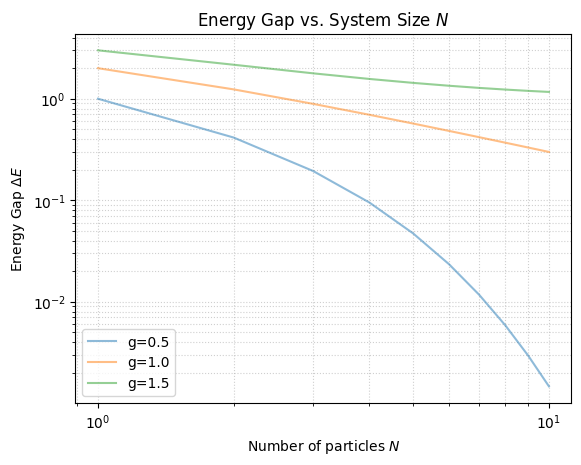

In [120]:
N = 10
Ns = np.arange(1,N + 1,1)

gap = np.full((N, n), np.nan)
eps = 0.0001

for k in range(0, N):
    for i in range(0,n):
        H = Hamiltonian(k + 1, j[i], g[i])
        eigvals = np.linalg.eigvalsh(H.full())
        # if len(eigvals) >= 2:
        #     print(eigvals[0], eigvals[1], eigvals[2])
        
        for jj in range (len(eigvals) - 1):
            if eigvals[jj + 1] - eigvals[jj] > eps:
                gap[k, i] = eigvals[jj + 1] - eigvals[jj]
                # print(i, gap[k,i], eigvals[jj], eigvals[jj + 1], jj)
                break
    

for i in range(n):
    # print(gap[:, i])
    plt.plot(Ns, gap[:, i], label=f'g={g[i]:.1f}', alpha=0.5)

plt.title(r'Energy Gap vs. System Size $N$')
plt.xlabel(r'Number of particles $N$')
plt.ylabel(r'Energy Gap $\Delta E$')
plt.grid(True, which='both', linestyle=':', alpha=0.6)
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()